In [1]:
import os
import jax
from jax import numpy as np, tree as jtu, random as jr

import equinox as eqx
from kneed import KneeLocator
from dLux import utils as dlu
from optax import sgd, adam, linear_schedule

import amigo as amg
from amigo import plotting
import dorito as drt
from dorito.stats import disco_regularised_loss_fn

# matplotlib configs
from matplotlib import pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots

plt.style.use(["science", "bright", "no-latex"])
new_rcParams = {
    "image.cmap": "inferno",
    "font.family": "serif",
    "image.origin": "lower",
    "figure.dpi": 300,
    "font.size": 8,
    "xtick.direction": "out",
    "ytick.direction": "out",
}
plt.rcParams.update(new_rcParams)

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

In [2]:
from frito.autoencoder.ae_utils import load_classes_from_file as lcf
from frito import (
    TransformedResolvedDiscoModel as TRDM,
    AutoencoderBasis,
    TransformedResolvedOIFit as TROIF,
    PointResolvedOIFit as PROIF,
    PointResolvedDiscoModel as PRDM,
)
from frito.utils import normalize_image
from frito.simulate import inject_image

In [3]:
master_key = jr.key(0)
main_data_path = "_data"
autoencoder_data_path = os.path.join(main_data_path, "autoencoder")
main_trained_model_path = os.path.join(autoencoder_data_path, "trained_models")
main_svd_path = os.path.join(autoencoder_data_path, "svd")
training_data_path = os.path.join(autoencoder_data_path, "training_data")
emnist_path = os.path.join(training_data_path, "emnist.npz")
mnist_path = os.path.join(training_data_path, "mnist.npz")
ppd_51_path = os.path.join(training_data_path, "fake_intensity_PPDs_51x51.npz")

main_out_path = "_output"
main_model_struct_path = "src/frito/autoencoder/model_structures"

ppd_51x51_data = np.load(ppd_51_path)
test_51x51_data = ppd_51x51_data["x_test"]
# test_51x51_data = np.clip(
#     test_51x51_data / np.sum(test_51x51_data, axis=(1, 2), keepdims=True),
#     0
# )
# test_51x51_data = np.clip(test_51x51_data, min=1e-8)
test_51x51_image = test_51x51_data[225]

disco_HD135344B_path = os.path.join(
    main_data_path, "jwst", "HD135344B", "disco", "cal_vis_HD135344B.npy"
)
disco_PDS70_path = os.path.join(
    main_data_path, "jwst", "PDS70", "disco", "bgmask_cal_vis_pds70.npy"
)
disco_PDS70 = np.load(disco_PDS70_path, allow_pickle=True).item()

In [4]:
model_key, master_key = jr.split(master_key, 2)
model_type = "PPD"
i = 0
model_names = ["7_4"]
model_name = model_names[i]
model_struct_path = os.path.join(
    main_model_struct_path, f"model_{model_name}.py"
)
trained_model_path = os.path.join(
    main_trained_model_path, model_type, f"{model_name}_best.eqx"
)
autoencoder_classes = lcf(model_struct_path)
autoencoder = autoencoder_classes["autoencoder"](key=model_key)
base_autoencoder = eqx.tree_deserialise_leaves(trained_model_path, autoencoder)
encoder, decoder = base_autoencoder.modules

print(f"Model: {model_name}")
print(f"Model Struct: {model_struct_path}")
print(f"Trained Model Path: {trained_model_path}")
print(f"Autoencoder Classes: {autoencoder_classes}")

Model: 7_4
Model Struct: src/frito/autoencoder/model_structures/model_7_4.py
Trained Model Path: _data/autoencoder/trained_models/PPD/7_4_best.eqx
Autoencoder Classes: {'autoencoder': <class 'model_7_4.autoencoder'>, 'decoder': <class 'model_7_4.decoder'>, 'encoder': <class 'model_7_4.encoder'>}


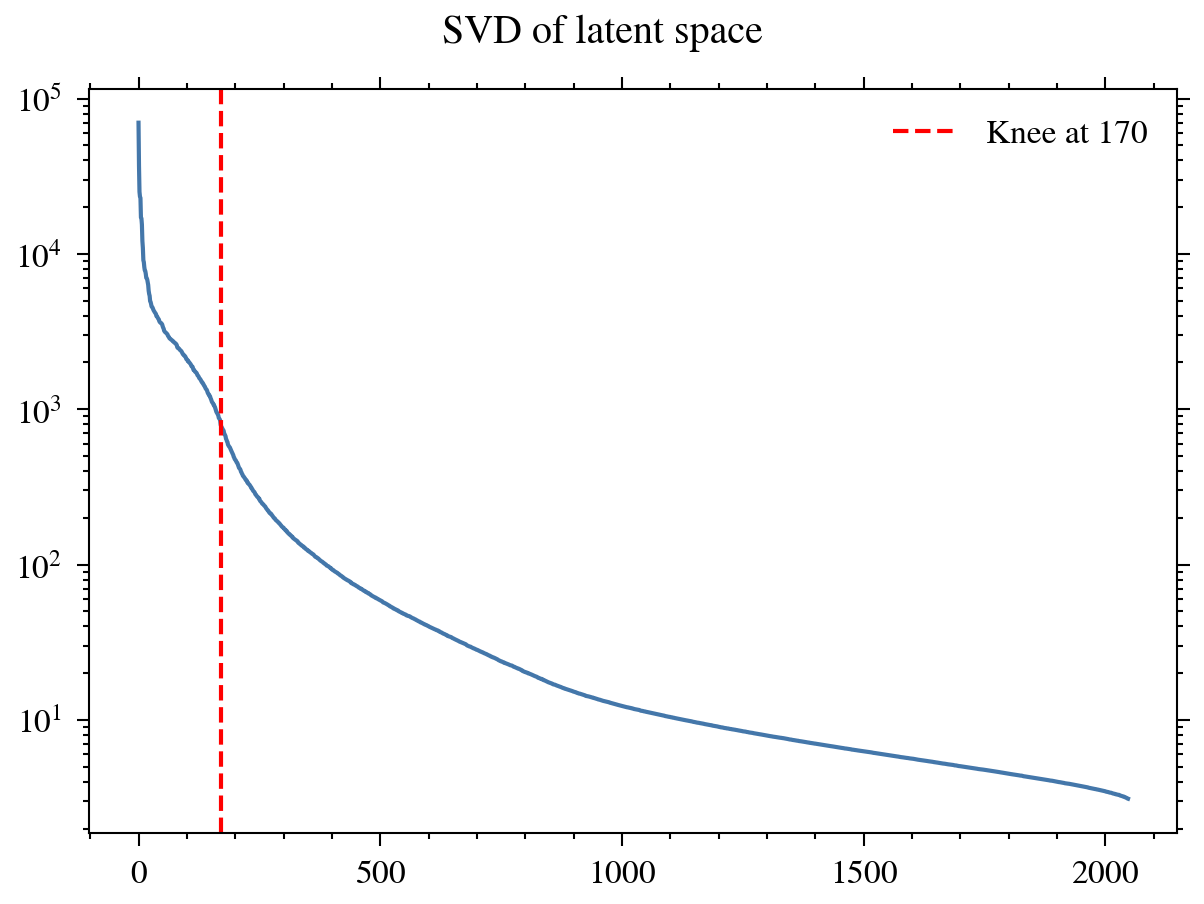

SVD Path: _data/autoencoder/svd/PPD_model_7_4_svd.npz
Knee at 170


In [5]:
svd_path = os.path.join(
    main_svd_path, f"{model_type}_model_{model_name}_svd.npz"
)
svd = np.load(svd_path)

k1 = KneeLocator(
    np.arange(len(svd["s"])),
    svd["s"],
    curve="convex",
    direction="decreasing",
    online=True,
)

fig, ax = plt.subplots(figsize=(4, 3), layout="constrained")
fig.suptitle("SVD of latent space")
ax.plot(svd["s"], marker=",")
ax.axvline(k1.knee, color="r", linestyle="--", label=f"Knee at {k1.knee}")
ax.legend()
ax.set_yscale("log")
plt.show()

print(f"SVD Path: {svd_path}")
print(f"Knee at {k1.knee}")

In [6]:
tmp_keys = jr.split(master_key, 3)
suture_keys = tmp_keys[:2]
master_key = tmp_keys[2]

new_encode_in = base_autoencoder.modules[0].layers[-1].in_features
new_encode_out = int(k1.knee)
new_encode_latent_weights = (
    base_autoencoder.modules[0].layers[-1].weight[:new_encode_out, :]
)
new_encode_latent_biases = (
    base_autoencoder.modules[0].layers[-1].bias[:new_encode_out]
)
new_encode_linear = eqx.nn.Linear(
    in_features=new_encode_in, out_features=new_encode_out, key=suture_keys[0]
)
trained_new_encode_linear = eqx.tree_at(
    lambda l: l.weight, new_encode_linear, new_encode_latent_weights
)
trained_new_encode_linear = eqx.tree_at(
    lambda l: l.bias, trained_new_encode_linear, new_encode_latent_biases
)
sutured_ae_struct = eqx.tree_at(
    lambda m: m.modules[0].layers[-1],
    base_autoencoder,
    trained_new_encode_linear,
)


def embed(X, knee, m, s, v):
    return (X - m[:knee]) @ v[:knee, :knee].T / np.sqrt(s[:knee] ** 2 / knee)


embed_layer = eqx.nn.Lambda(
    lambda z: embed(z, int(k1.knee), svd["mean"], svd["s"], svd["v"])
)
sutured_ae_struct = eqx.tree_at(
    lambda m: m.modules[0].layers,
    sutured_ae_struct,
    sutured_ae_struct.modules[0].layers + [embed_layer],
)


def unembed(embedded, knee, m, s, v):
    return ((embedded) * np.sqrt(s[:knee] ** 2 / knee)) @ v[:knee, :knee] + m[
        :knee
    ]


unembed_layer = eqx.nn.Lambda(
    lambda z: unembed(z, int(k1.knee), svd["mean"], svd["s"], svd["v"])
)
sutured_ae_struct = eqx.tree_at(
    lambda m: m.modules[1].layers,
    sutured_ae_struct,
    [unembed_layer] + sutured_ae_struct.modules[1].layers,
)

new_decode_out = sutured_ae_struct.modules[1].layers[2].out_features
new_decode_in = int(k1.knee)
new_decode_latent_weights = (
    sutured_ae_struct.modules[1].layers[2].weight[:, :new_decode_in]
)
new_decode_latent_biases = sutured_ae_struct.modules[1].layers[2].bias
new_decode_linear = eqx.nn.Linear(
    in_features=new_decode_in, out_features=new_decode_out, key=suture_keys[1]
)
trained_new_decode_linear = eqx.tree_at(
    lambda l: l.weight, new_decode_linear, new_decode_latent_weights
)
trained_new_decode_linear = eqx.tree_at(
    lambda l: l.bias, trained_new_decode_linear, new_decode_latent_biases
)
sutured_ae_struct = eqx.tree_at(
    lambda m: m.modules[1].layers[2],
    sutured_ae_struct,
    trained_new_decode_linear,
)

sutured_model_path = os.path.join(
    main_trained_model_path, model_type, f"{model_name}_Rbest.eqx"
)
sutured_ae = eqx.tree_deserialise_leaves(sutured_model_path, sutured_ae_struct)
print(f"Suture Model Path: {sutured_model_path}")

encoder, decoder = sutured_ae.modules

# def sum2unity(X):
#     return X / np.sum(X, axis=(1, 2), keepdims=True)


# sum2unity_layer = eqx.nn.Lambda(lambda z: sum2unity(z))
# norm_sutured_ae = eqx.tree_at(
#     lambda m: m.modules[1].layers,
#     sutured_ae,
#     sutured_ae.modules[1].layers + [sum2unity_layer],
# )

# encoder, decoder = norm_sutured_ae.modules

Suture Model Path: _data/autoencoder/trained_models/PPD/7_4_Rbest.eqx


In [7]:
decoder(encoder(test_51x51_image.reshape(1, 51, 51))).shape

(1, 51, 51)

In [8]:
np.sum(decoder(encoder(test_51x51_image.reshape(1, 51, 51)))[0])

Array(350.98337, dtype=float32)

In [9]:
np.sum(test_51x51_image)

Array(356.24554, dtype=float32)

Text(0.5, 1.0, 'Autoencoded Simulated Disk')

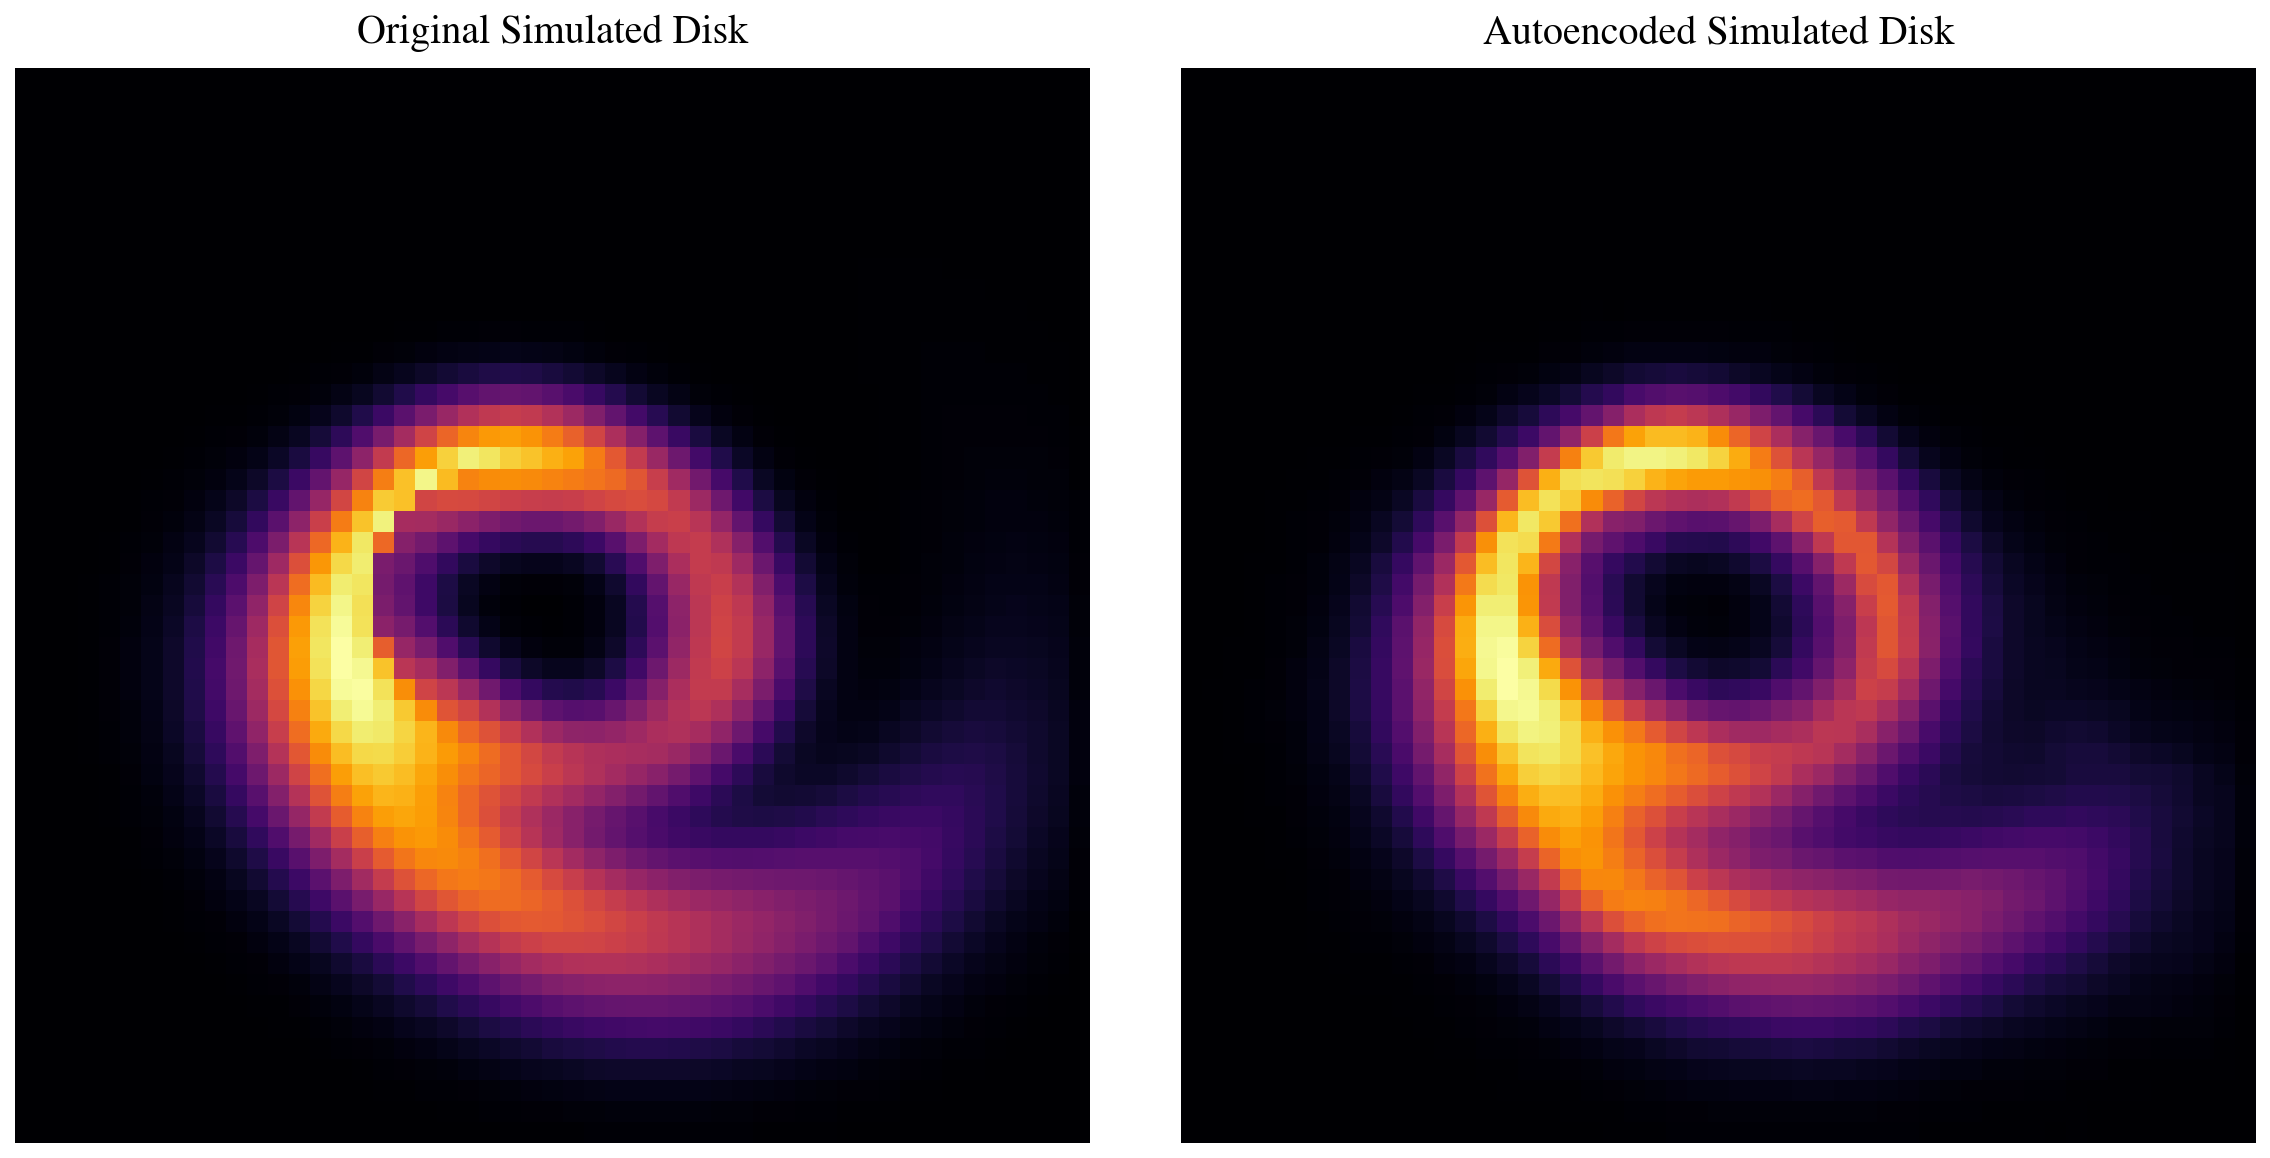

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4), layout="tight")
ax[0].imshow(test_51x51_image)
ax[0].set_axis_off()
ax[0].set_title("Original Simulated Disk")
ax[1].imshow(decoder(encoder(test_51x51_image.reshape(1, 51, 51)))[0])
ax[1].set_axis_off()
ax[1].set_title("Autoencoded Simulated Disk")

Text(0.5, 1.0, 'Initial Distribution | Sum: 897.18896484375')

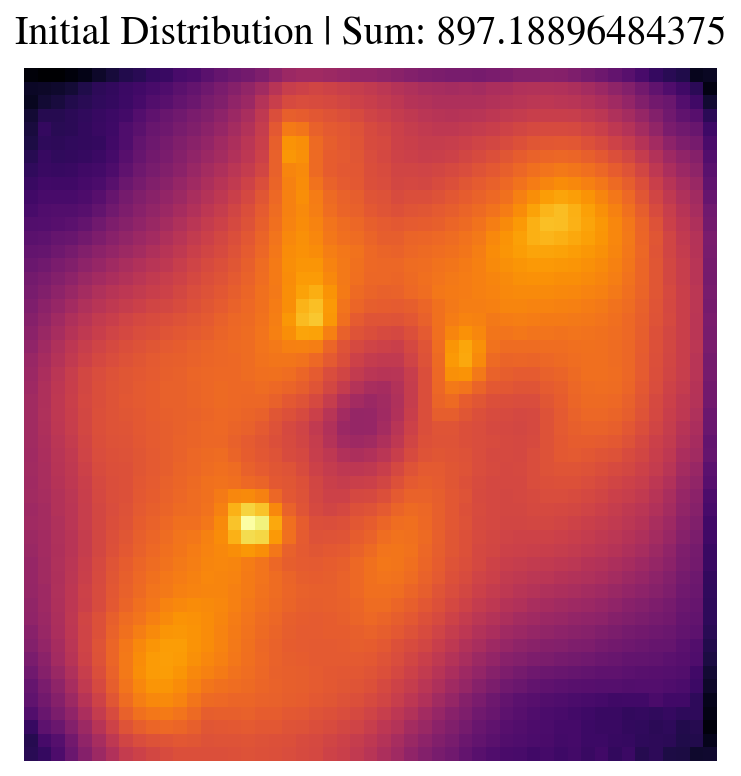

In [11]:
init_latent = np.zeros((170,))
init_dist = decoder(init_latent)[0]
# init_dist = normalize_image(test_51x51_image)
# init_dist = test_51x51_image
fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(init_dist)
ax.set_axis_off()
ax.set_title(f"Initial Distribution | Sum: {np.sum(init_dist)}")

In [12]:
sim_noise_key, master_key = jr.split(master_key, 2)
disco_sim = inject_image(
    disco_PDS70, test_51x51_image, add_noise=True, key=sim_noise_key
)

/Users/jonahgoldfine/Documents/Important Documents/packages/frito/src/frito/utils.py:58: UserWarning: Explicitly requested dtype float64 requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  img = np.asarray(img, dtype=np.float64)
/Users/jonahgoldfine/Documents/Important Documents/packages/frito/.venv/lib/python3.11/site-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
/Users/jonahgoldfine/Documents/Important Documents/packages

In [13]:
optics_diameter = 6.603464
otf_coords = dlu.pixel_coords(51, 2 * optics_diameter)
# basis = AutoencoderBasis(norm_sutured_ae)
basis = AutoencoderBasis(sutured_ae)
ois = [
    PROIF(
        oi_data,
        key,
        filter=key,
    )
    for key, oi_data in disco_sim.items()
]

In [14]:
test_51x51_image.min()/test_51x51_image.max()

np.float32(5.721273e-17)

In [15]:
model = PRDM(
    ois=ois,
    distribution=init_dist,
    basis=basis,
    uv_npixels=2 * otf_coords.shape[-1],
    uv_pscale=0.5 * np.diff(otf_coords[0, 0]).mean(),
    oversample=2.0,
    contrast = .1,
    rotate=False
)

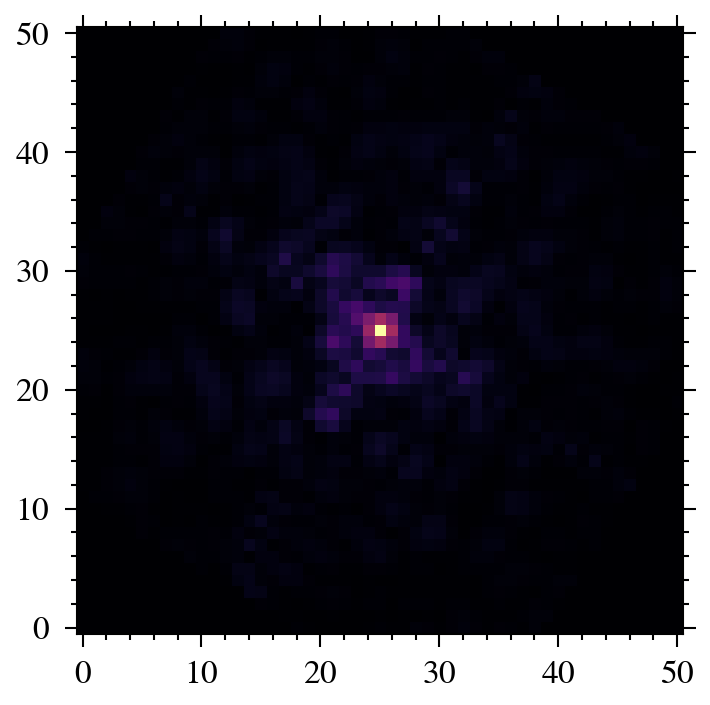

In [16]:
oi = ois[0]
dirty_image = oi.dirty_image(model)
plt.imshow(dirty_image)

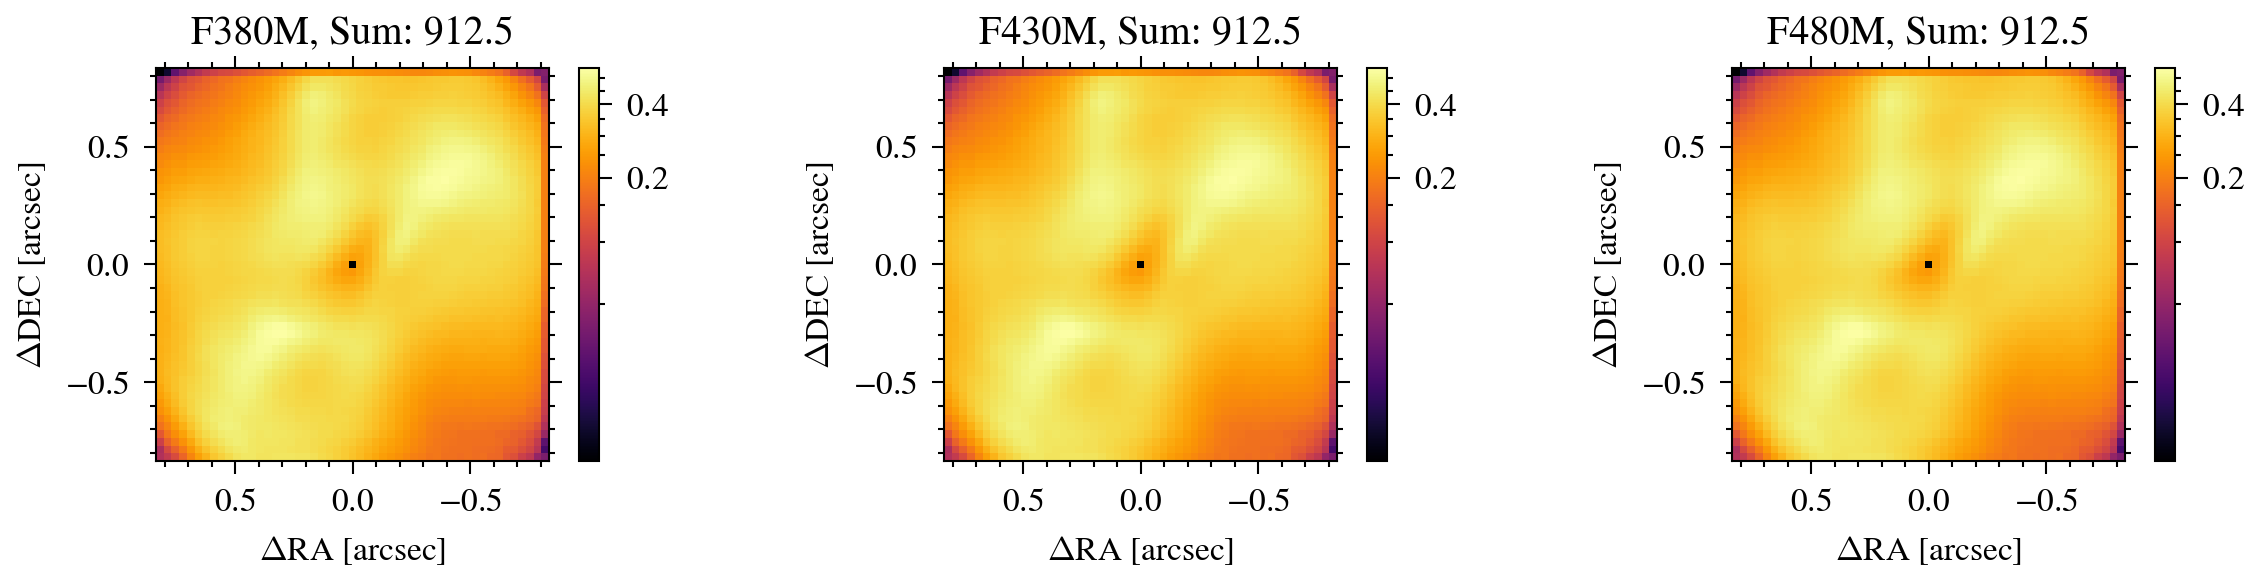

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(8, 2))

for idx, oi in enumerate(ois):
    init_dist = model.get_distribution(oi, exponentiate=False)

    c0 = drt.plotting.plot_result(
        ax[idx],
        init_dist.at[init_dist.shape[0] // 2, init_dist.shape[1] // 2].set(
            np.nan
        ),
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        cmap=inferno,
        norm=mpl.colors.PowerNorm(0.3),
    )
    fig.colorbar(c0, ax=ax[idx])
    ax[idx].set(title=f"{oi.filter}, Sum: {init_dist.sum():.1f}")

plt.tight_layout()
plt.show()

In [23]:
def norm_fn(model_params, args):
    params = model_params.params

    # NOTE: This normalisation won't work for an arbitrary basis!
    if "log_dist" in params.keys():
        for k, log_dist in params["log_dist"].items():
            # distribution = 10**log_dist
            # log_dist = np.log10(distribution / distribution.sum())

            # basis = args["basis"]
            # window = args["window"]
            # distribution = 10 ** basis.from_basis(log_dist) * window
            # distribution = gaussian_filter(distribution, sigma=sig)
            # distribution += 1e-16 * ((window + 1) % 2)
            # log_dist = np.log10(distribution / distribution.sum())
            # log_dist = basis.to_basis(log_dist)
            # params["log_dist"][k] = log_dist/np.sum(log_dist)
            params['log_dist'][k] = log_dist

    return model_params.set("params", params), args


def grad_fn(model, grads, args):

    # Reduce spectra gradients for the science exposures
    # if "spectra" in config.keys():
    #     grads = grads.multiply(spc_keys, 0.3)

    # if "fluxes" in config.keys():
    #     # grads = grads.multiply(flx_keys, 2)
    #     grads = grads.multiply(flx_keys, 5)
    # if "positions" in config.keys():
    #     # grads = grads.multiply(pos_keys, 0.5)
    #     grads = grads.multiply(pos_keys, 5)

    return grads, args


n_epoch = 20_000#2000
config = {
    # "log_dist": adam(1e-3, 0),
    # "log_dist": adam(linear_schedule(1e-8, 1e-3, 5000, 1500)),
    "log_dist": adam(5e-7,0), #adam(1e-5, 0),
    "contrast": sgd(1e-8, 0),
    # "contrast": sgd(2e-8, 100),
    # "log_dist": adam(5e-3, 0),
}
args = {
    "reg_dict": {
        # "TV": (1e0, drt.stats.TV),
    },
    "basis": basis,
}
trainer = amg.fitting.Trainer(
    loss_fn=disco_regularised_loss_fn, norm_fn=norm_fn, grad_fn=grad_fn
)
trainer = trainer.update_fishers(
    model=model,
    exposures=[],
    parameters=[],
)

0it [00:00, ?it/s]

full rank identity applied to phase amplitude

In [24]:
result = trainer.train(
    model=model,
    optimisers=config,
    epochs=n_epoch,
    batches=ois,
    args=args,
)

  0%|          | 0/20000 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 113,594,408.00
Compiling Loss function...
Compiling update function...
Estimated run time: 3:12:15
Full Time: 0:49:07
Final Loss: 180,740,784.00


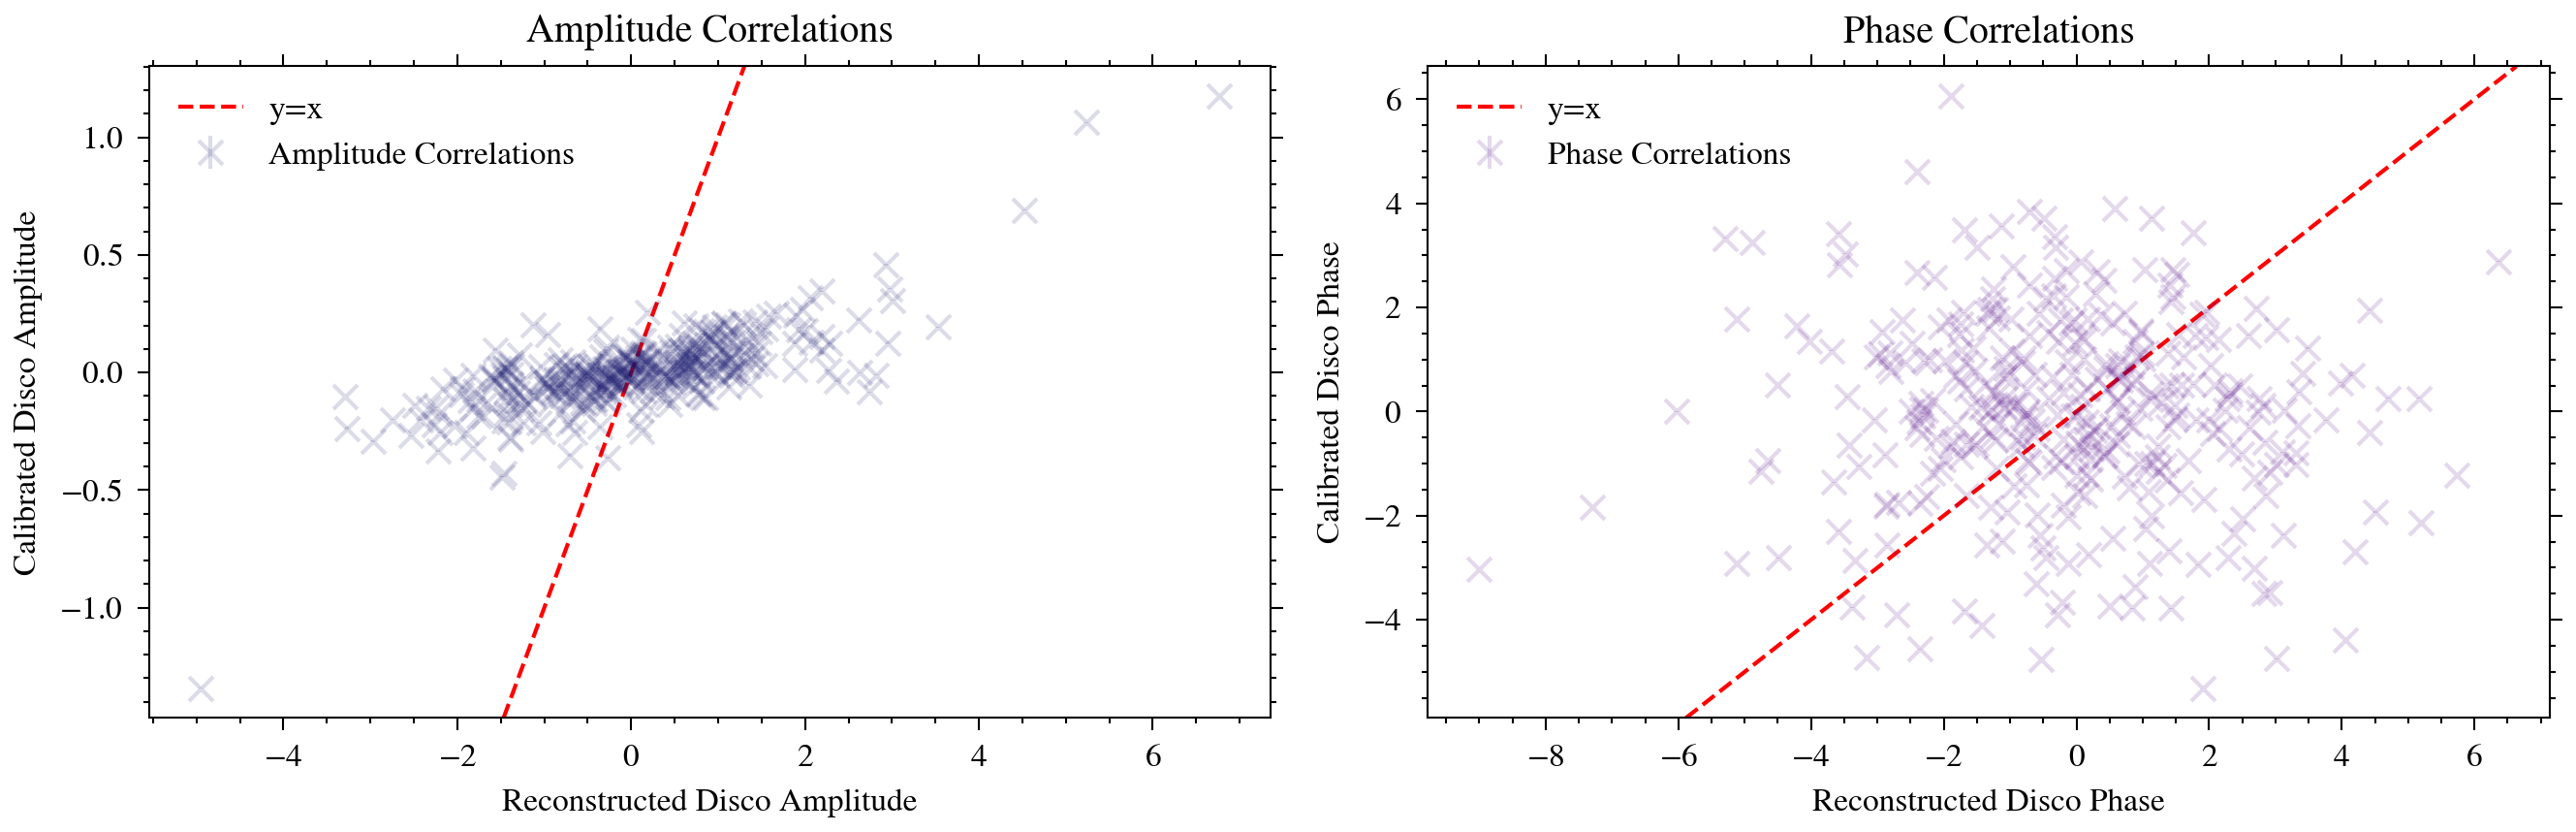

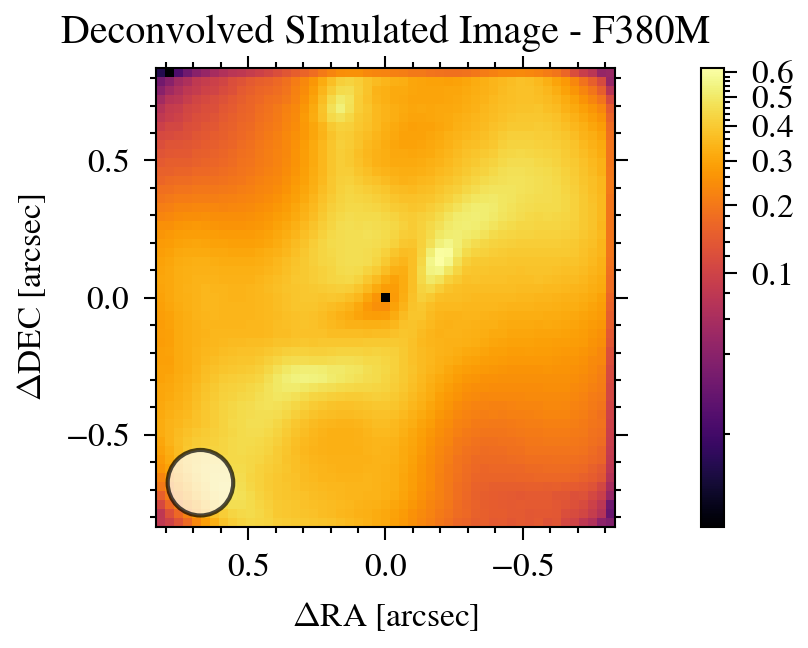

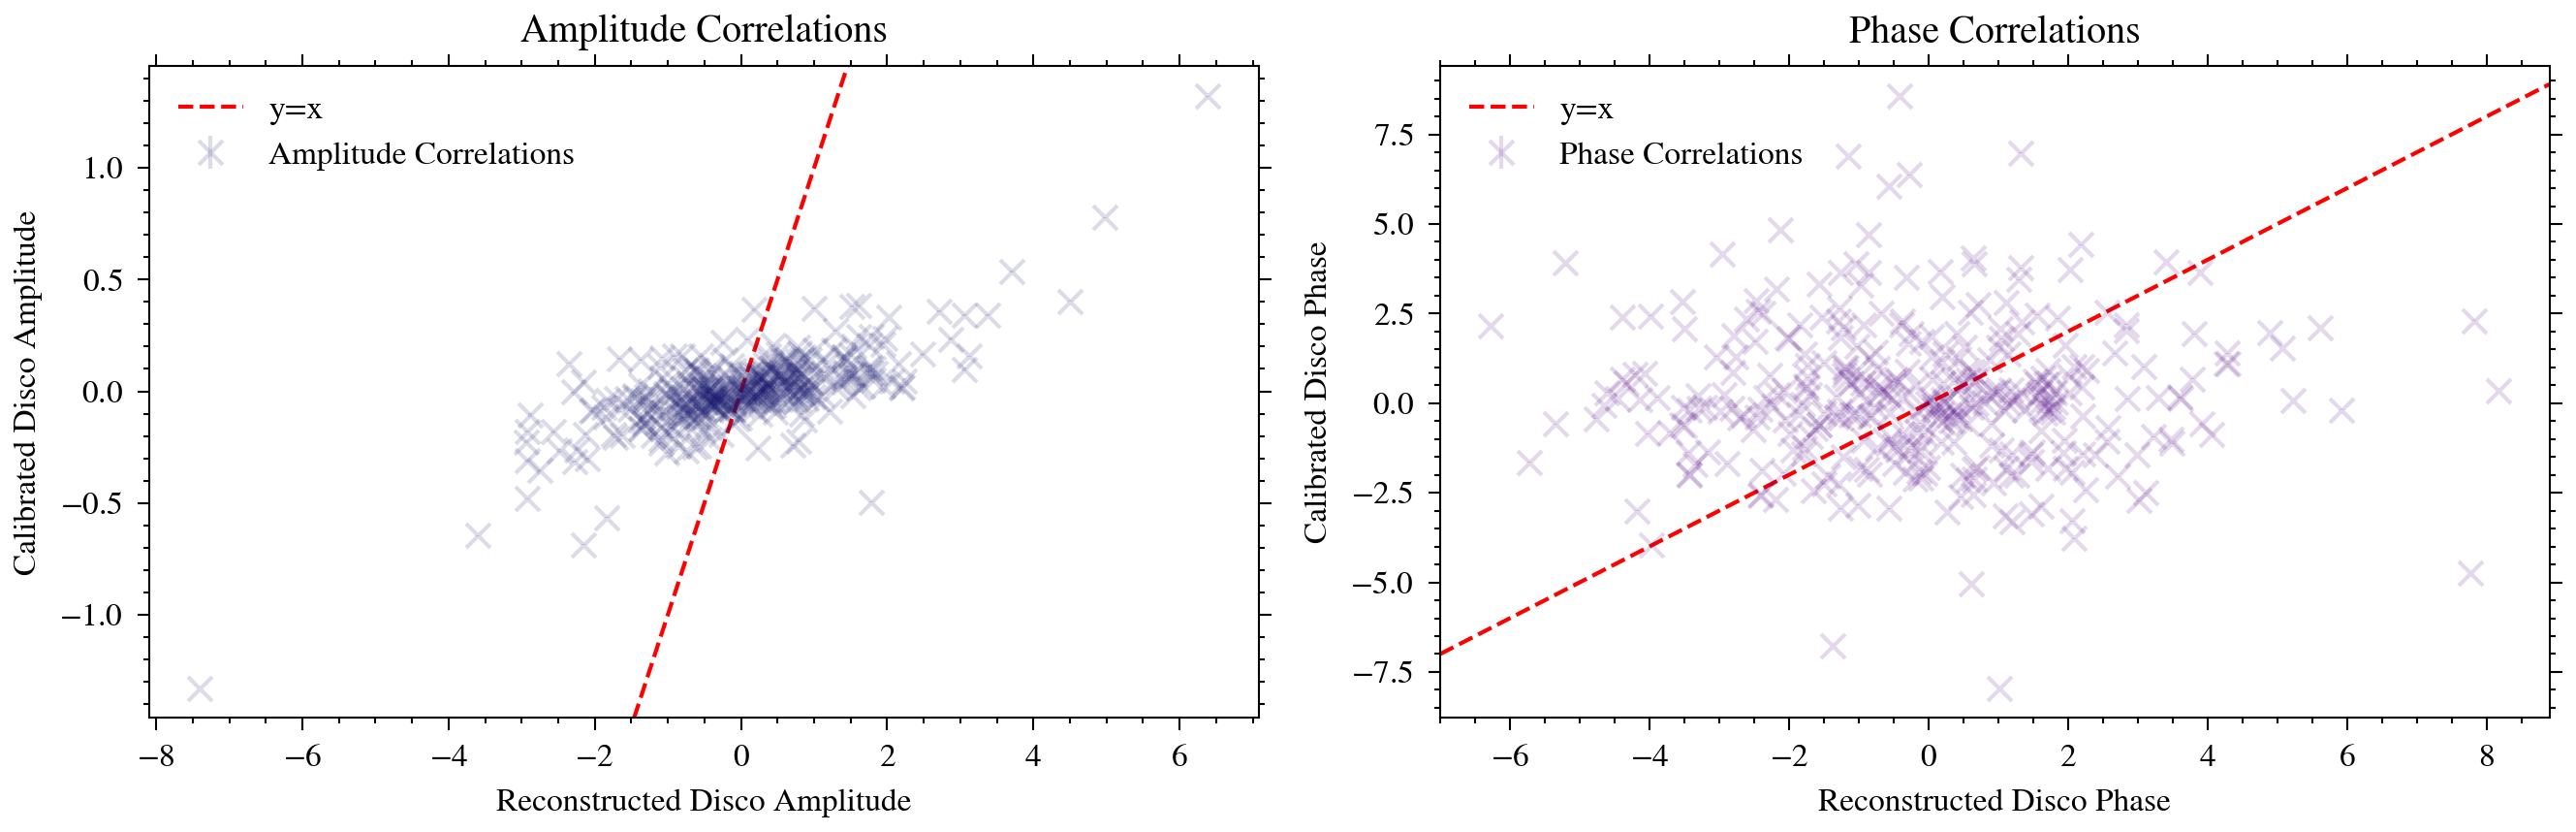

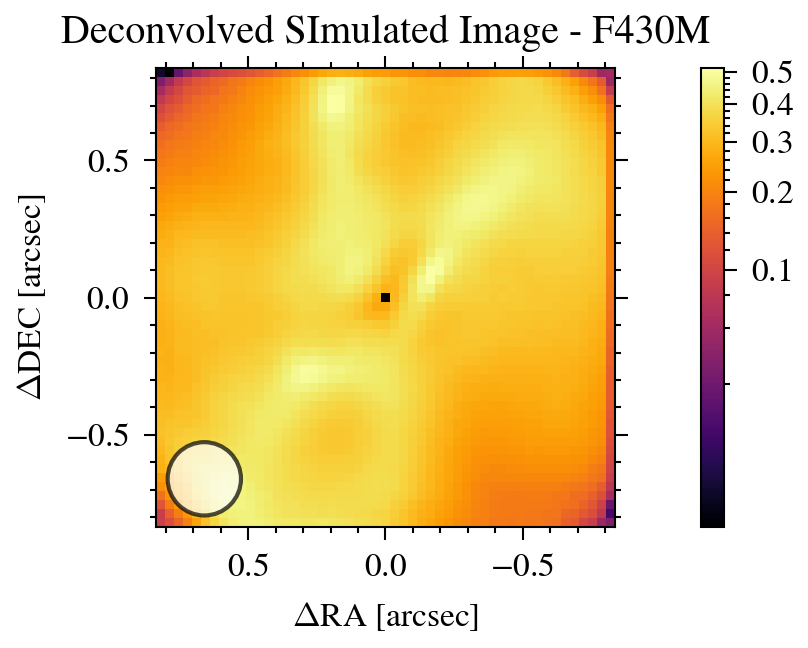

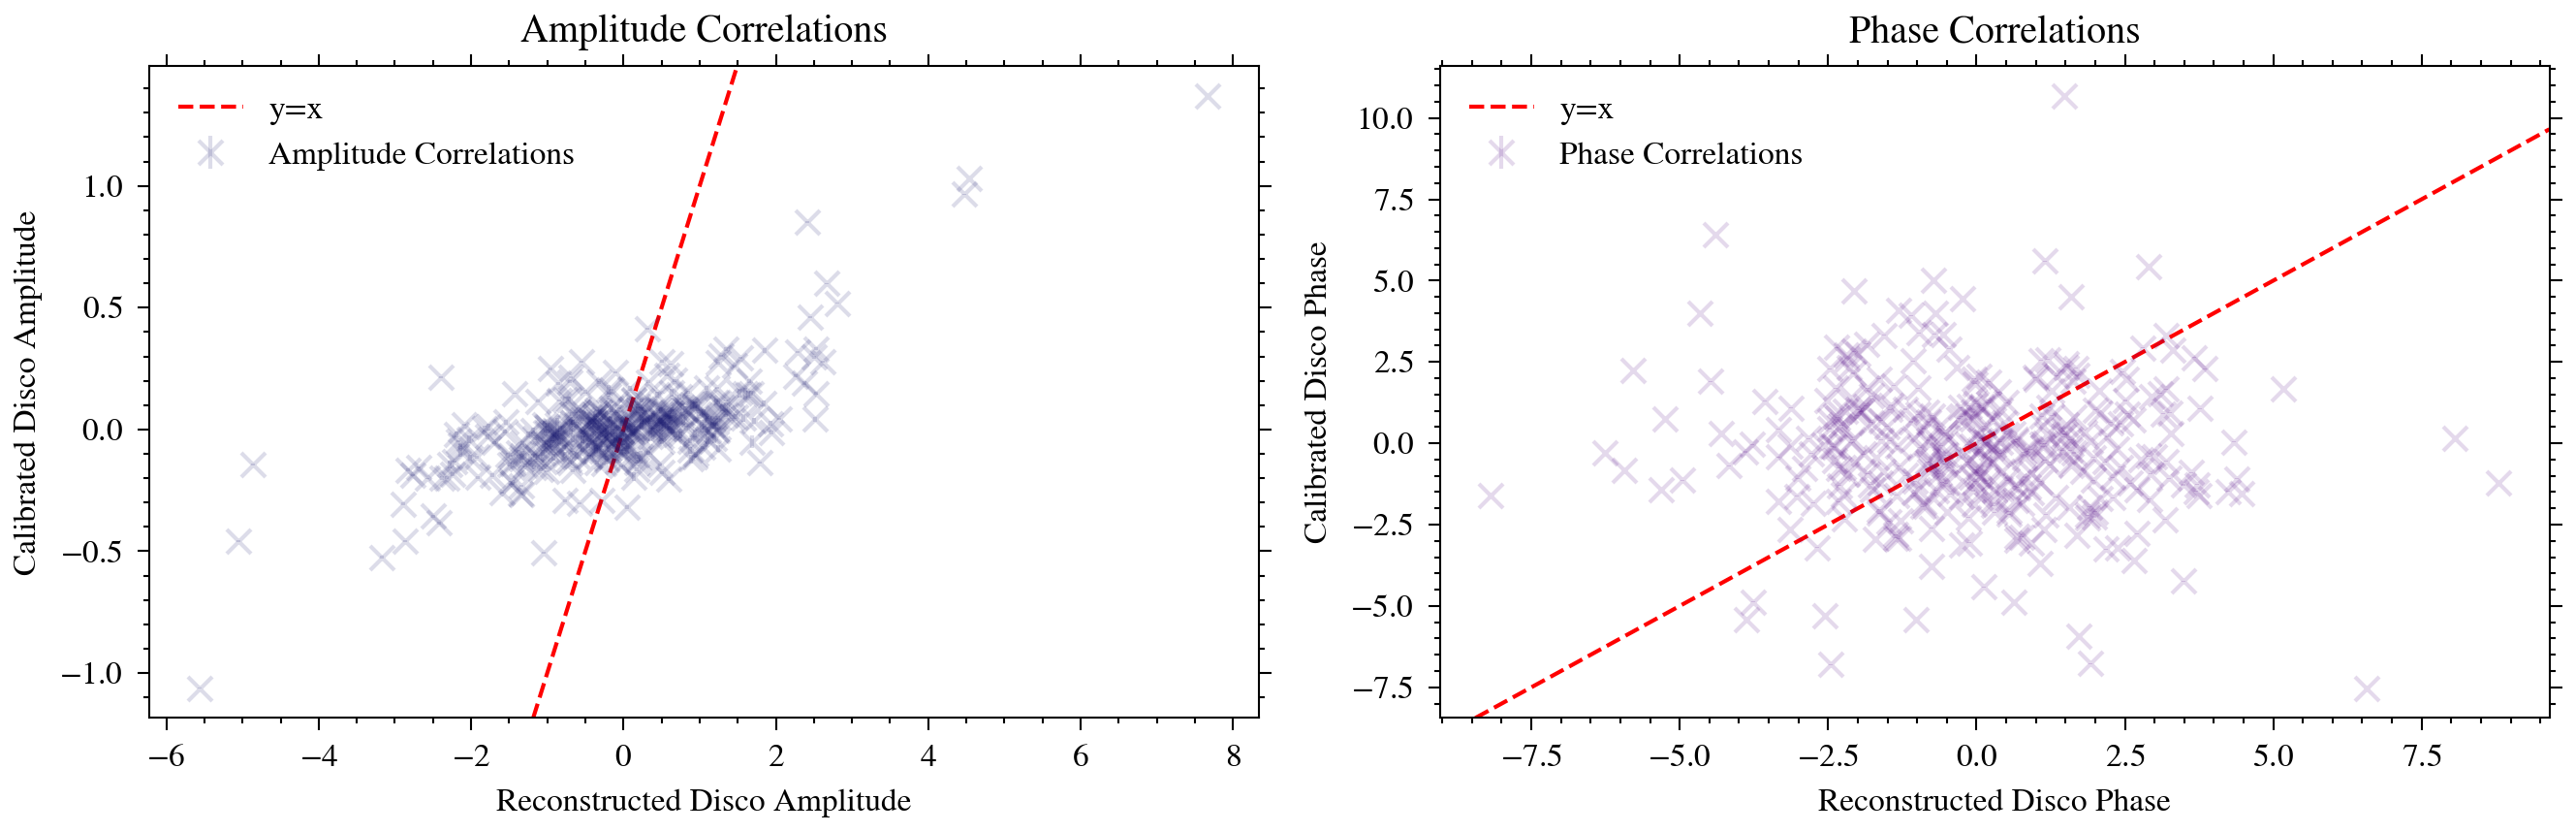

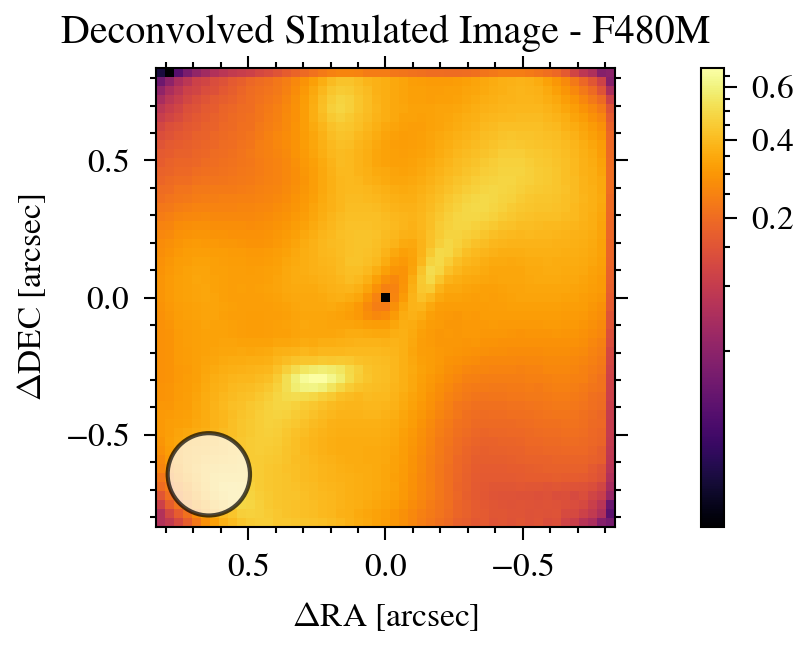

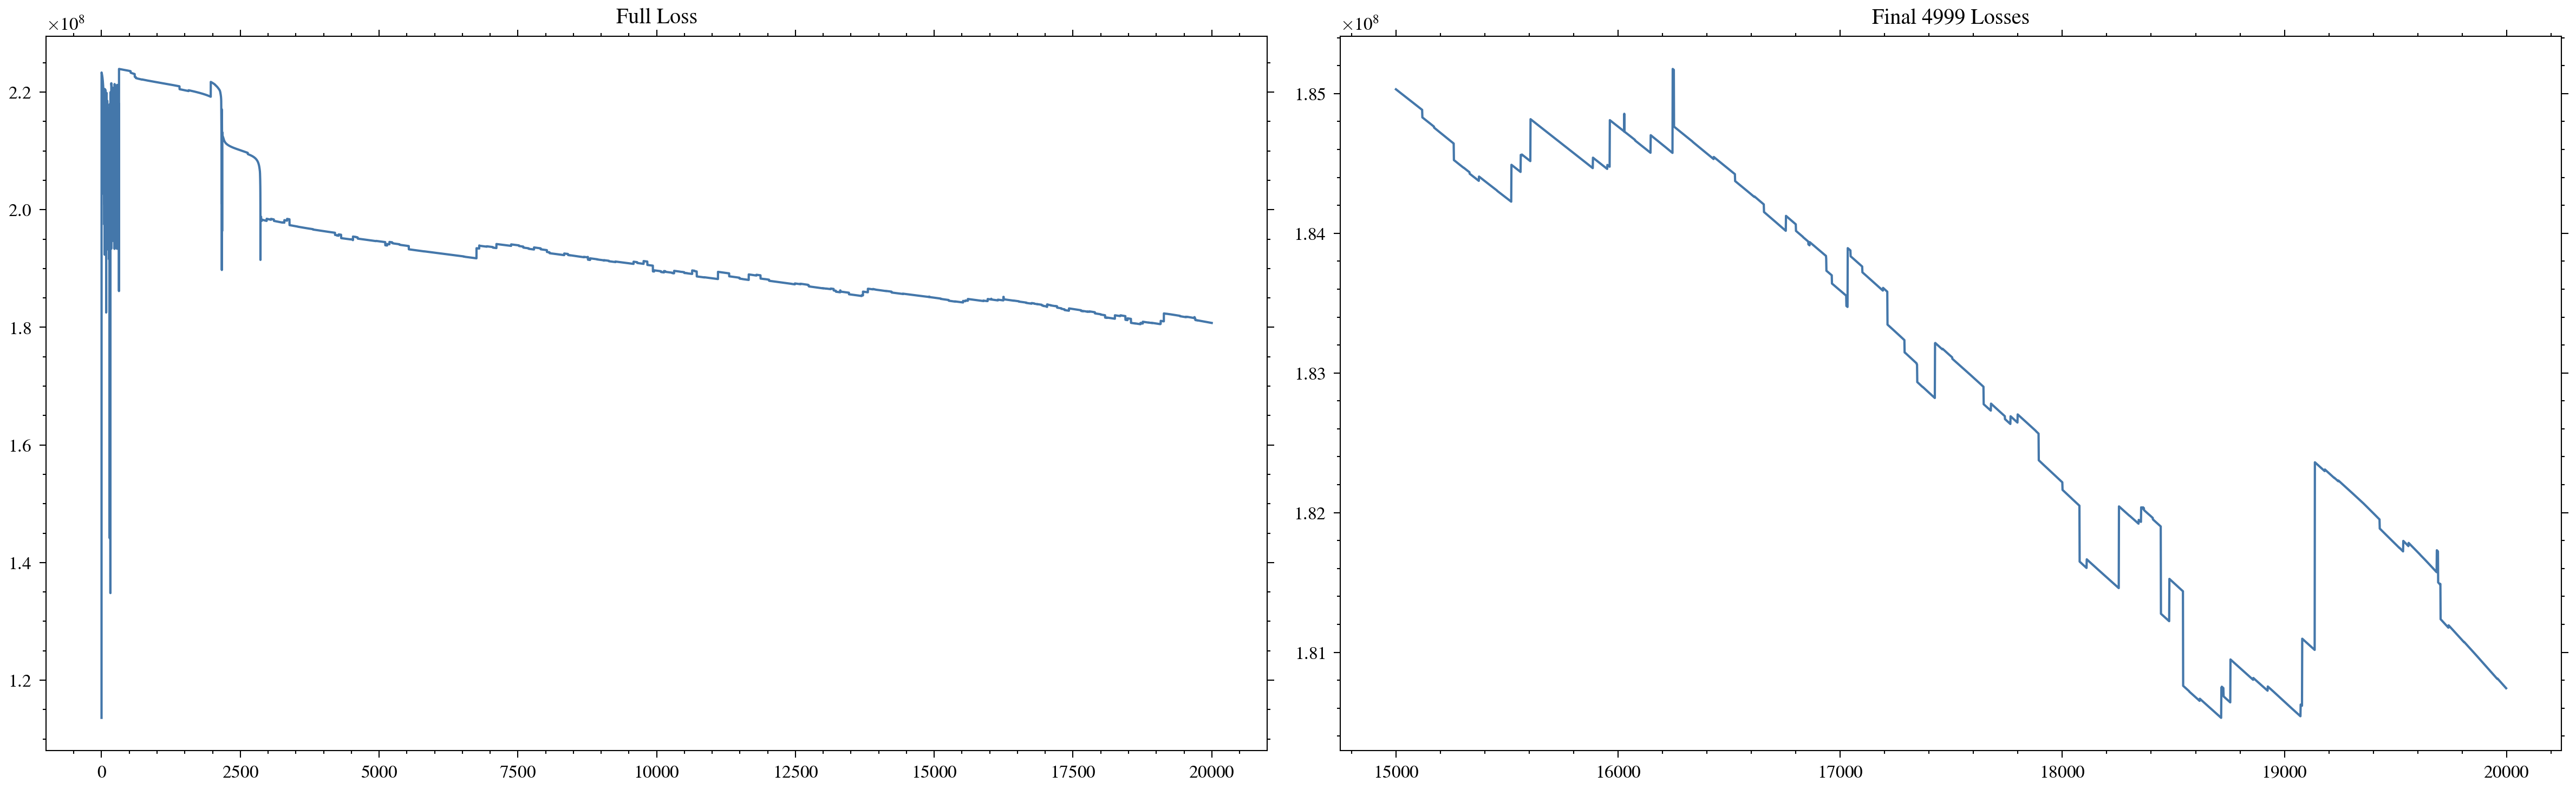

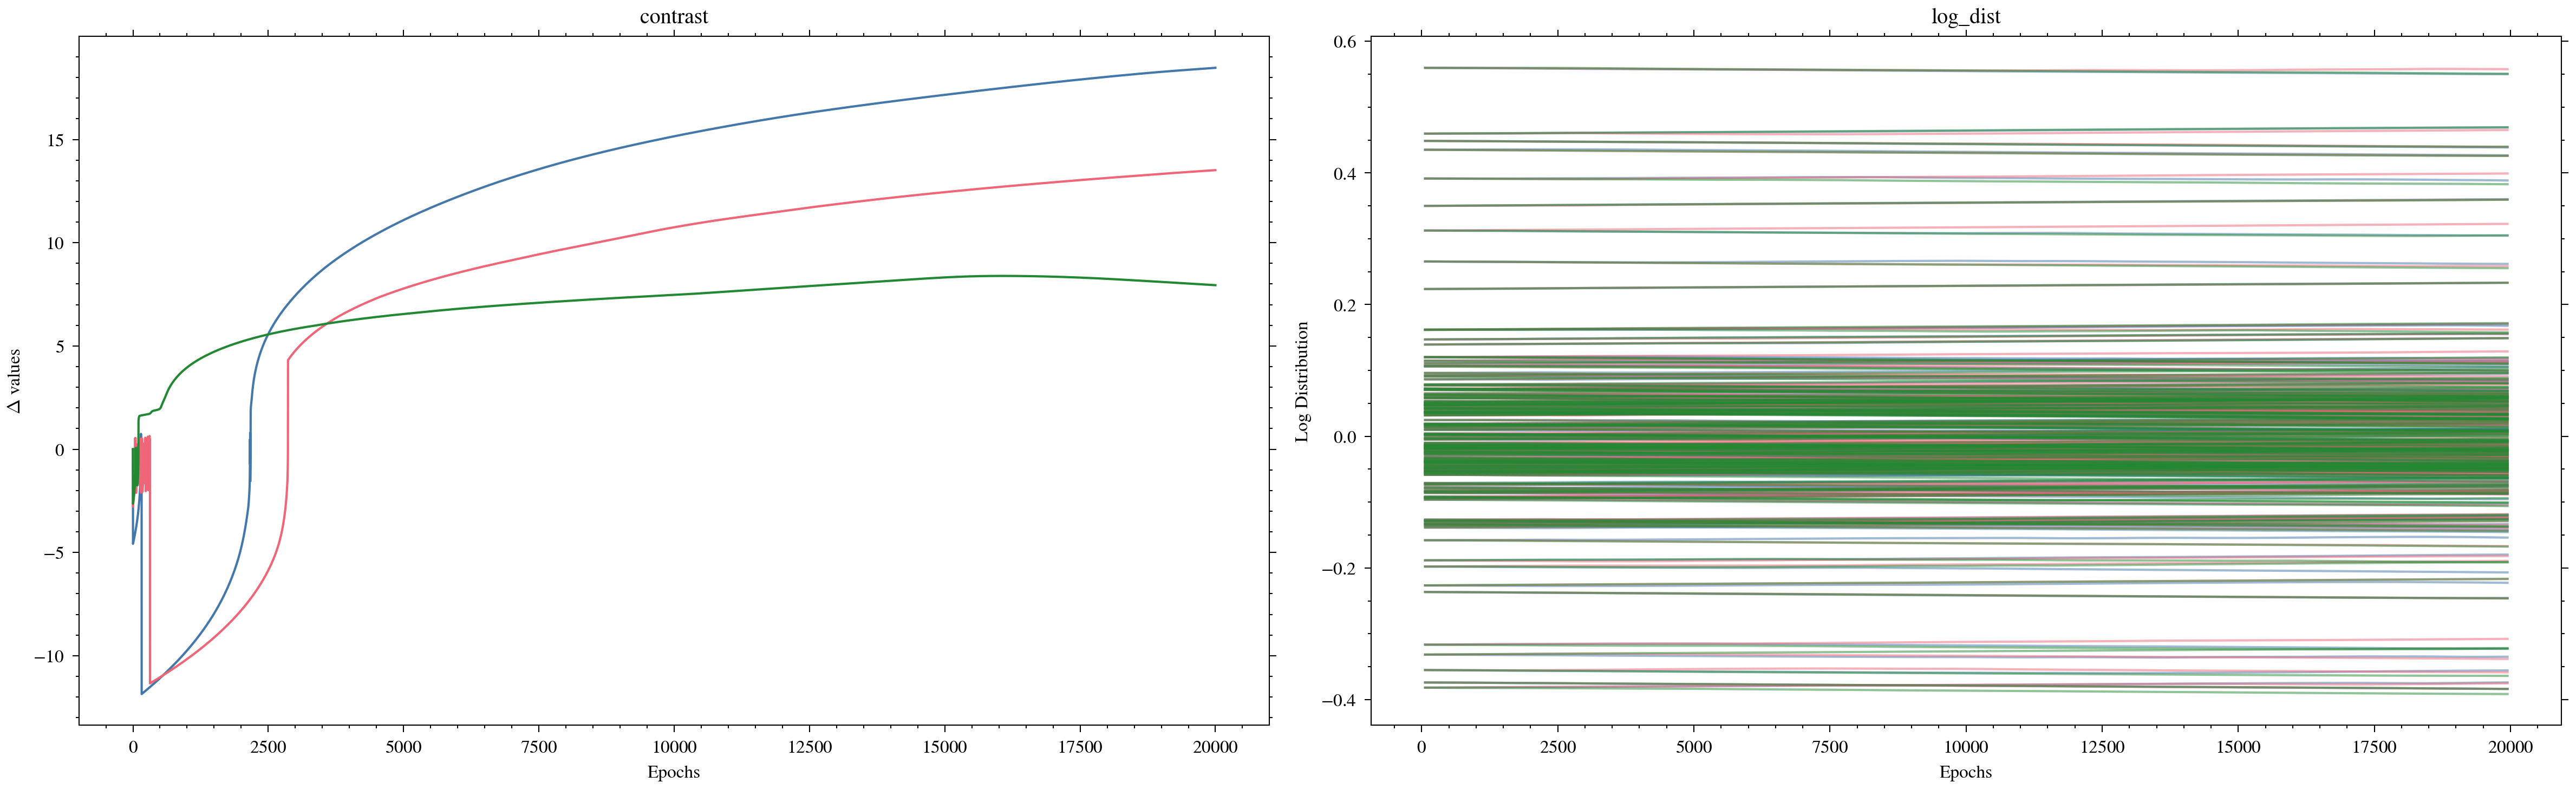

In [25]:
for oi in ois:
    dist = result.model.get_distribution(oi, exponentiate=False)
    n = dist.shape[0]  # <-- grab the size from the distribution itself

    disco_amp, disco_phase = np.split(oi(result.model), 2)

    # # PLOT THE CORRELATIONS

    fig, ax = plt.subplots(1, 2, figsize=(9, 3), sharey=False)

    ax[0].errorbar(
        disco_amp,
        oi.vis,
        yerr=oi.d_vis,
        label="Amplitude Correlations",
        fmt="x",
        alpha=0.15,
        color="midnightblue",
    )
    ax[0].axline((0, 0), slope=1, color="red", linestyle="--", label="y=x")
    ax[0].set_title("Amplitude Correlations")
    ax[0].set_xlabel("Reconstructed Disco Amplitude")
    ax[0].set_ylabel("Calibrated Disco Amplitude")
    ax[0].legend()

    ax[1].errorbar(
        disco_phase,
        oi.phi,
        yerr=oi.d_phi,
        label="Phase Correlations",
        fmt="x",
        alpha=0.15,
        color="indigo",
    )
    ax[1].axline((0, 0), slope=1, color="red", linestyle="--", label="y=x")
    ax[1].set_title("Phase Correlations")
    ax[1].set_xlabel("Reconstructed Disco Phase")
    ax[1].set_ylabel("Calibrated Disco Phase")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

    # # PLOT THE DISTRIBUTINO

    fig, ax = plt.subplots(figsize=(6, 2.3))
    c0 = drt.plotting.plot_result(
        ax,
        dist.at[init_dist.shape[0] // 2, init_dist.shape[1] // 2].set(
            np.nan
        ),
        pixel_scale=dlu.rad2arcsec(result.model.pscale_in),
        cmap=inferno,
        diff_lim = dlu.rad2arcsec(oi.wavel / optics_diameter),
        norm=mpl.colors.PowerNorm(0.3),
        # scale=2.0
    )

    fig.colorbar(c0)
    # c0 = drt.plotting.plot_result(
    #     ax,
    #     dist,
    #     pixel_scale=dlu.rad2arcsec(model.pscale_in),
    #     cmap=inferno,
    #     norm=mpl.colors.PowerNorm(0.9, vmin=0),
    #     roll_angle_degrees=-oi.parang,
    #     diff_lim=dlu.rad2arcsec(oi.wavel / optics_diameter),
    #     scale=2.0,
    # )

    # fig.colorbar(c0)

    ax.set(
        title=f"Deconvolved SImulated Image - {oi.key}",
    )

    plt.tight_layout()
    plt.show()

plotting.plot_losses(result.losses[0], start=int(n_epoch * 0.75))
plotting.plot(result.history)

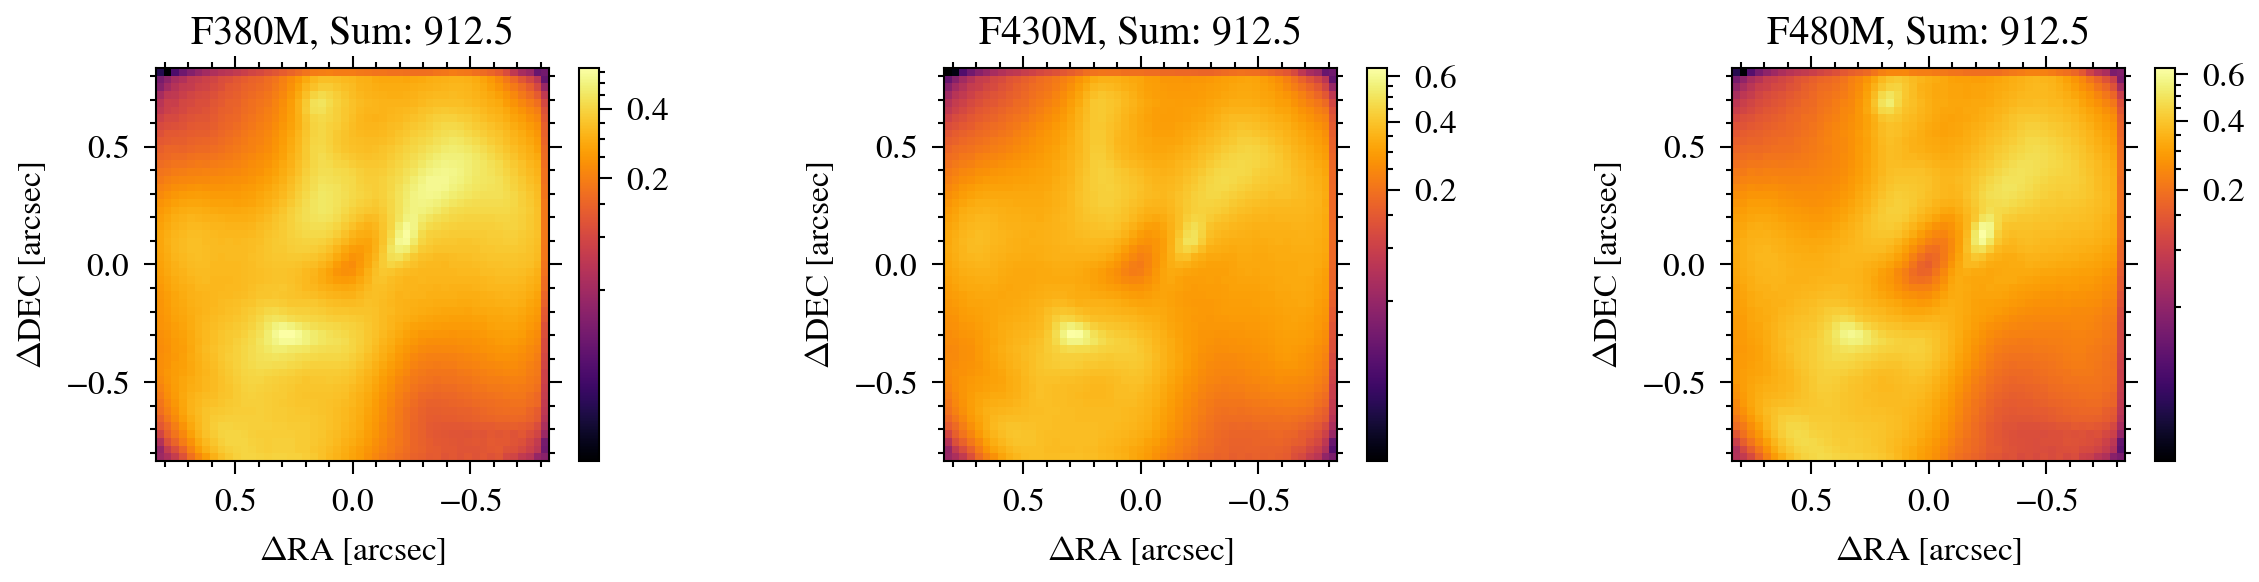

In [22]:
fig, ax = plt.subplots(1, 3, figsize=(8, 2))

for idx, oi in enumerate(ois):
    dist = result.model.get_distribution(oi, exponentiate=False)

    c0 = drt.plotting.plot_result(
        ax[idx],
        # dist.at[init_dist.shape[0] // 2, init_dist.shape[1] // 2].set(
        #     np.nan
        # ),
        dist,
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        cmap=inferno,
        norm=mpl.colors.PowerNorm(0.3),
    )
    fig.colorbar(c0, ax=ax[idx])
    ax[idx].set(title=f"{oi.filter}, Sum: {init_dist.sum():.1f}")

plt.tight_layout()
plt.show()

In [ ]:
result.model.get_distribution(oi, exponentiate=False)

SyntaxError: invalid syntax (2914448736.py, line 1)

In [42]:
def noise(array,noise_factor,key): #! Make uniform noise scale as X% of RMS
    normal_key,uniform_key=jax.random.split(key,2)
    if noise_factor==None:
        noise_factor=jax.random.uniform(uniform_key,shape=(array.shape[0]),minval=0.0,maxval=0.5) 
        # print(noise_factor)
    elif noise_factor=='RMS':
        noise_factor = 0.1 * np.sqrt(np.mean(array**2, axis = (1,2,3)))
    else:
        assert isinstance(noise_factor, (int, float)), "Noise_Factor must be 'RMS', None, Int, or Float" 
        noise_factor = np.full((array.shape[0],), noise_factor)
    noise_factor = noise_factor.reshape(array.shape[0], 1, 1, 1)
    # print(noise_factor.shape)
    noisy_array=array+noise_factor*jax.random.normal(normal_key,array.shape)
    return np.clip(noisy_array,0,1.)

In [46]:
test_noise = noise(test_51x51_image.reshape(1,1,51,51), 'RMS', jr.key(0))

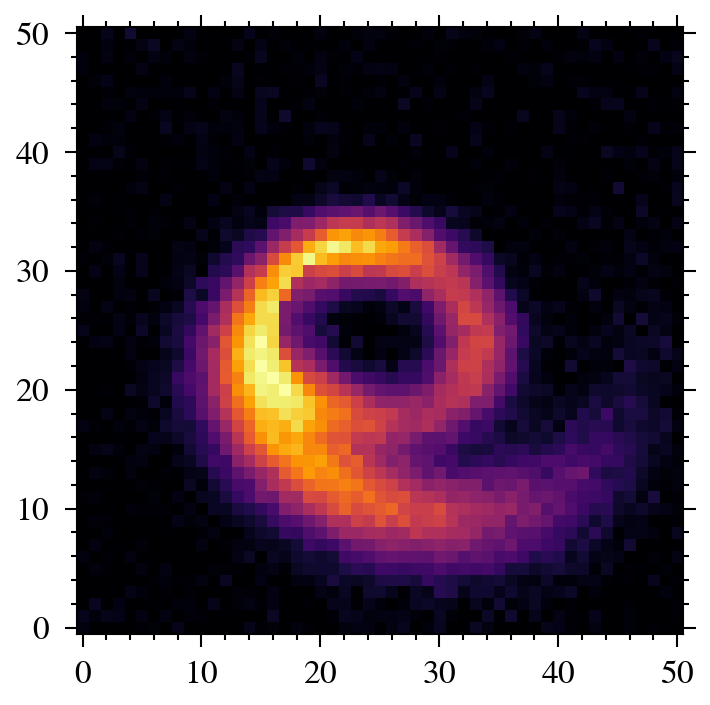

In [52]:
plt.imshow(test_noise[0,0]/np.sum(test_noise[0,0]))